<a href="https://colab.research.google.com/github/bisu617/ai-misinformation-detection/blob/main/model-stage2/Roberta.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

 Mounting Drive + Installing Libraries

In [ ]:

from google.colab import drive
drive.mount('/content/drive')

!pip install -q transformers datasets accelerate evaluate scikit-learn


Mounted at /content/drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.8 MB/s eta 0:00:00


 Checking GPU

In [ ]:
import torch
print('CUDA available:', torch.cuda.is_available())
print('Device:', torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU')

CUDA available: True
Device: Tesla T4


Loading Dataset


In [ ]:

import pandas as pd

# CHANGE THIS to your actual dataset path in Drive
DATASET_PATH = '/content/drive/MyDrive/merged_cleaned_misinfo.csv'

df = pd.read_csv(DATASET_PATH)

print('Shape:', df.shape)
print('Columns:', df.columns.tolist())
print('\nLabel distribution:')
print(df['final_int'].value_counts())
print('\nSample:')
print(df[['clean_text', 'final_int']].head(3))


Shape: (99144, 14)
Columns: ['id', 'title', 'text', 'text_input', 'source_label', 'misinfo_label', 'final_label', 'final_int', 'model', 'watermarked', 'topic', 'split', 'generator_model', 'clean_text']

Label distribution:
final_int
0.0    39452
1.0     9692
Name: count, dtype: int64

Sample:
                                          clean_text  final_int
0  census data released with assistance from imf ...        0.0
1  national education association has awarded 120...        0.0
2  overview fda has issued updated guidelines req...        0.0


/tmp/ipykernel_2471/4005013047.py:9: DtypeWarning: Columns (3,8) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(DATASET_PATH)


Prepare Train / Val / Test Split

In [ ]:

from sklearn.model_selection import train_test_split

# Use clean_text as input and final_int as label
df = df[['clean_text', 'final_int']].copy()
df = df.rename(columns={'clean_text': 'text', 'final_int': 'label'})

# Clean up
df['text']  = df['text'].astype(str).str.strip()
# Drop rows where 'label' is NaN before converting to int
df = df.dropna(subset=['label'])
df['label'] = df['label'].astype(int)
df = df[df['text'].str.len() >= 30]
df = df[df['label'].isin([0, 1])]
df = df.drop_duplicates(subset=['text'])
df = df.reset_index(drop=True)

print('Cleaned shape:', df.shape)
print('Label distribution:')
print(df['label'].value_counts())

# Split: 80% train, 10% val, 10% test
train_df, temp_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['label'])
val_df,  test_df  = train_test_split(temp_df, test_size=0.5, random_state=42, stratify=temp_df['label'])

print(f'\nTrain: {train_df.shape}')
print(f'Val:   {val_df.shape}')
print(f'Test:  {test_df.shape}')

Cleaned shape: (48766, 2)
Label distribution:
label
0    39217
1     9549
Name: count, dtype: int64

Train: (39012, 2)
Val:   (4877, 2)
Test:  (4877, 2)


In [ ]:

from datasets import Dataset
from transformers import AutoTokenizer

model_name = 'roberta-base'
tokenizer  = AutoTokenizer.from_pretrained(model_name)

train_ds = Dataset.from_pandas(train_df.reset_index(drop=True))
val_ds   = Dataset.from_pandas(val_df.reset_index(drop=True))
test_ds  = Dataset.from_pandas(test_df.reset_index(drop=True))

def tokenize(batch):
    return tokenizer(batch['text'], truncation=True, max_length=128, padding='max_length')

train_tok = train_ds.map(tokenize, batched=True, remove_columns=['text'])
val_tok   = val_ds.map(tokenize,   batched=True, remove_columns=['text'])
test_tok  = test_ds.map(tokenize,  batched=True, remove_columns=['text'])

train_tok.set_format('torch')
val_tok.set_format('torch')
test_tok.set_format('torch')

print('Tokenization done!')
print(train_tok)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/39012 [00:00<?, ? examples/s]

Map:   0%|          | 0/4877 [00:00<?, ? examples/s]

Map:   0%|          | 0/4877 [00:00<?, ? examples/s]

Tokenization done!
Dataset({
    features: ['label', 'input_ids', 'attention_mask'],
    num_rows: 39012
})


In [ ]:

import numpy as np
import evaluate
from transformers import (
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding
)

id2label = {0: 'factual',        1: 'misinformation'}
label2id = {'factual': 0, 'misinformation': 1}

model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=2,
    id2label=id2label,
    label2id=label2id
)

acc_metric = evaluate.load('accuracy')
f1_metric  = evaluate.load('f1')

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        'accuracy': acc_metric.compute(predictions=preds, references=labels)['accuracy'],
        'f1':       f1_metric.compute(predictions=preds,  references=labels, average='binary')['f1']
    }

print('Model loaded!')

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.out_proj.weight      | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model loaded!


In [ ]:

args = TrainingArguments(
    output_dir='roberta_stage2',
    eval_strategy='steps',
    eval_steps=500,
    save_steps=500,
    logging_steps=100,
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    num_train_epochs=3,
    weight_decay=0.01,
    fp16=False,
    load_best_model_at_end=True,
    metric_for_best_model='f1',
    greater_is_better=True,
    report_to='none'
)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)
torch.cuda.empty_cache()

trainer = Trainer(
    model=model,
    args=args,
    train_dataset=train_tok,
    eval_dataset=val_tok,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

In [ ]:

train_result = trainer.train()
print('\nTraining complete!')
print(f"Total train time : {train_result.metrics['train_runtime']:.1f}s")
print(f"Train samples/sec: {train_result.metrics['train_samples_per_second']:.1f}")

Step,Training Loss,Validation Loss,Accuracy,F1
500,0.099963,0.153348,0.972114,0.923337
1000,0.059512,0.083169,0.975190,0.933844
1500,0.075298,0.077886,0.977445,0.938889
2000,0.069184,0.063505,0.977650,0.940535
2500,0.081319,0.060479,0.979496,0.944812
3000,0.116768,0.078665,0.976830,0.938218
3500,0.070623,0.057325,0.979496,0.944751
4000,0.052211,0.066423,0.977445,0.939427
4500,0.055702,0.052691,0.979701,0.945334
5000,0.066845,0.054623,0.979701,0.945334


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye


Training complete!
Total train time : 3443.3s
Train samples/sec: 34.0


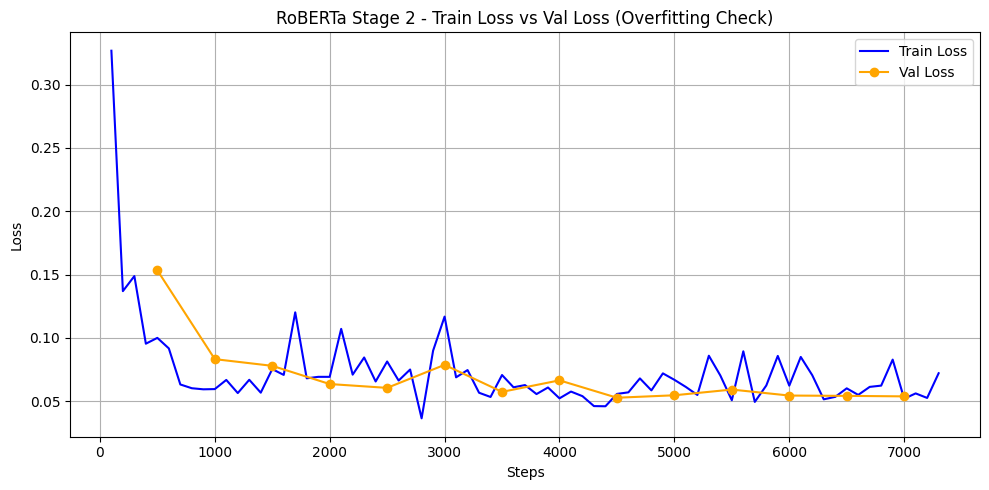

Overfitting plot saved!


In [ ]:

import matplotlib.pyplot as plt

logs = trainer.state.log_history

train_steps  = [x['step'] for x in logs if 'loss' in x and 'eval_loss' not in x]
train_losses = [x['loss'] for x in logs if 'loss' in x and 'eval_loss' not in x]
val_steps    = [x['step'] for x in logs if 'eval_loss' in x]
val_losses   = [x['eval_loss'] for x in logs if 'eval_loss' in x]

plt.figure(figsize=(10, 5))
plt.plot(train_steps, train_losses, label='Train Loss', color='blue')
plt.plot(val_steps,   val_losses,   label='Val Loss',   color='orange', marker='o')
plt.xlabel('Steps')
plt.ylabel('Loss')
plt.title('RoBERTa Stage 2 - Train Loss vs Val Loss (Overfitting Check)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/AI_Humanizer/overfitting_stage2.png', dpi=150)
plt.show()
print('Overfitting plot saved!')

In [ ]:

test_results = trainer.evaluate(test_tok)
print('\n========== FINAL TEST RESULTS (STAGE 2) ==========')
print(f"Accuracy : {test_results['eval_accuracy']:.4f}")
print(f"F1 Score : {test_results['eval_f1']:.4f}")
print(f"Eval Loss: {test_results['eval_loss']:.4f}")
print('===================================================')



========== FINAL TEST RESULTS (STAGE 2) ==========
Accuracy : 0.9779
F1 Score : 0.9401
Eval Loss: 0.0562



=== Classification Report ===
                precision    recall  f1-score   support

       Factual       0.97      1.00      0.99      3922
Misinformation       1.00      0.89      0.94       955

      accuracy                           0.98      4877
     macro avg       0.99      0.94      0.96      4877
  weighted avg       0.98      0.98      0.98      4877



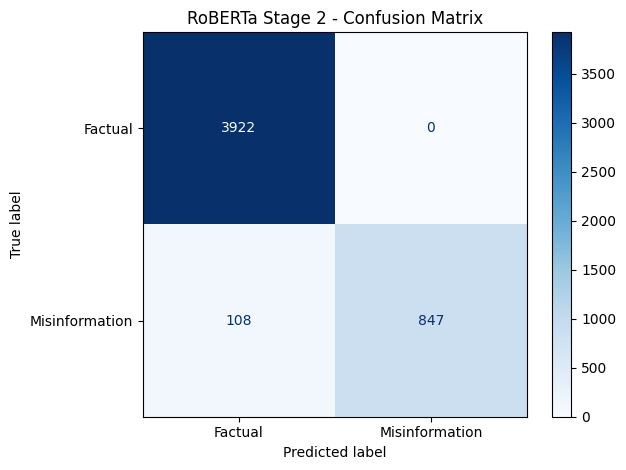

Confusion matrix saved!


In [ ]:

from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

preds_output = trainer.predict(test_tok)
y_pred = np.argmax(preds_output.predictions, axis=-1)
y_true = preds_output.label_ids

print('\n=== Classification Report ===')
print(classification_report(y_true, y_pred, target_names=['Factual', 'Misinformation']))

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Factual', 'Misinformation'])
disp.plot(cmap='Blues')
plt.title('RoBERTa Stage 2 - Confusion Matrix')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/AI_Humanizer/confusion_matrix_stage2.png', dpi=150)
plt.show()
print('Confusion matrix saved!')

In [ ]:
# CELL 12:
save_path = '/content/drive/MyDrive/AI_Humanizer/roberta_stage2_model'
trainer.save_model(save_path)
tokenizer.save_pretrained(save_path)
print('Stage 2 model saved to:', save_path)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Stage 2 model saved to: /content/drive/MyDrive/AI_Humanizer/roberta_stage2_model


In [ ]:
# CELL 13: Full Two-Stage Pipeline Test
from transformers import AutoTokenizer, AutoModelForSequenceClassification

# Load Stage 1 model
stage1_tokenizer = AutoTokenizer.from_pretrained('/content/drive/MyDrive/AI_Humanizer/roberta_stage1_model')
stage1_model     = AutoModelForSequenceClassification.from_pretrained('/content/drive/MyDrive/AI_Humanizer/roberta_stage1_model')
stage1_model.eval()

# Load Stage 2 model
stage2_tokenizer = AutoTokenizer.from_pretrained(save_path)
stage2_model     = AutoModelForSequenceClassification.from_pretrained(save_path)
stage2_model.eval()

def run_pipeline(text):
    #Stage 1
    inputs1 = stage1_tokenizer(text, return_tensors='pt', truncation=True, max_length=128, padding=True)
    with torch.no_grad():
        out1 = stage1_model(**inputs1)
    probs1  = torch.softmax(out1.logits, dim=-1)
    pred1   = torch.argmax(probs1, dim=-1).item()
    conf1   = probs1[0][pred1].item()
    label1  = stage1_model.config.id2label[pred1].upper()

    print(f"\n{'='*55}")
    print(f"Input: {text[:80]}...")
    print(f"{'='*55}")
    print(f"Stage 1 → {label1} (Confidence: {conf1*100:.2f}%)")

    if label1 == 'HUMAN':
        print("Stage 2 → SKIPPED (Human-written text)")
        print(f"Final   → HUMAN WRITTEN — Not misinformation")
        return

    # Stage 2 (only if AI)
    inputs2 = stage2_tokenizer(text, return_tensors='pt', truncation=True, max_length=128, padding=True)
    with torch.no_grad():
        out2 = stage2_model(**inputs2)
    probs2  = torch.softmax(out2.logits, dim=-1)
    pred2   = torch.argmax(probs2, dim=-1).item()
    conf2   = probs2[0][pred2].item()
    label2  = stage2_model.config.id2label[pred2].upper()

    print(f"Stage 2 → {label2} (Confidence: {conf2*100:.2f}%)")
    print(f"Final   → AI-GENERATED {label2}")

# Test the full pipeline
test_texts = [
    "honestly i dont even know what to do lol my laptop keeps crashing",
    "Artificial intelligence refers to the simulation of human intelligence by machines.",
    "Scientists have confirmed that drinking coffee every morning increases lifespan by 20 years according to a new study.",
    "The mitochondria generates most of the cell's supply of adenosine triphosphate used as chemical energy.",
]

for text in test_texts:
    run_pipeline(text)

OSError: Repo id must be in the form 'repo_name' or 'namespace/repo_name': '/content/drive/MyDrive/AI_Humanizer/roberta_stage1_model'. Use `repo_type` argument if needed.